# Simulation of Vessel Trajectories & Anomalies

Use the config file to adjust the number of vessels, obstacles, speed limits, ...

In [46]:
import logging
from datetime import datetime, timedelta
import json

from model import ShipModel
from agents.ship import Ship

logging.basicConfig(
    filename="notebook_logs.log",
    filemode="w",  # Overwrites on each run; use "a" to append
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

config_file="config/config.json"
with open(config_file) as f:
    config = json.load(f)

steps = config["simulation_steps"]
    
model = ShipModel(
        width=config["width"],
        height=config["height"],
        num_ships=config["num_ships"],
        max_speed_range=config["max_speed_range"],
        speed_variation=config["speed_variation"],
        directional_variation=config["directional_variation"],
        ports=config["ports"],
        speed_limit_zones=config.get("speed_limit_zones", []),
        obstacles=config["obstacles"],
        dwa_config=config["dwa_config"],
        resolution=config["resolution"],
        obstacle_threshold=config["obstacle_threshold"],
        lookahead=config["lookahead"]
    )

for type, agents in model.agents_by_type.items():
    print(f'{type}: {len(agents)}')

for ship in model.agents.select(agent_type=Ship):
    print(f"Ship {ship.unique_id} has a maximum speed of {ship.original_max_speed}.")

<class 'agents.obstacle.Obstacle'>: 3
<class 'agents.port.Port'>: 10
<class 'agents.ship.Ship'>: 8
Ship 0 has a maximum speed of 10.399239384976237.
Ship 1 has a maximum speed of 8.06018886458498.
Ship 2 has a maximum speed of 6.131874406583917.
Ship 3 has a maximum speed of 11.548115867422904.
Ship 4 has a maximum speed of 6.022526831385471.
Ship 5 has a maximum speed of 10.033920752022082.
Ship 6 has a maximum speed of 5.00498120224951.
Ship 7 has a maximum speed of 6.250128426728087.


## Trajectory Simulation

In [47]:
t0 = datetime.now()
print(f"{datetime.now()} Starting ...")
for t in range(steps):
    stride = 50
    if t%stride == 0:
        print(f"Steps {t} - {t+stride-1}...")
    model.step()
t1 = datetime.now()
print(f"{datetime.now()} Finished in {t1-t0}.")

2025-09-04 11:04:58.963295 Starting ...
Steps 0 - 49...
Steps 50 - 99...
Steps 100 - 149...
Steps 150 - 199...
Steps 200 - 249...
Steps 250 - 299...
Steps 300 - 349...
Steps 350 - 399...
Steps 400 - 449...
Steps 450 - 499...
Steps 500 - 549...
Steps 550 - 599...
Steps 600 - 649...
Steps 650 - 699...
Steps 700 - 749...
Steps 750 - 799...
Steps 800 - 849...
Steps 850 - 899...
Steps 900 - 949...
Steps 950 - 999...
Steps 1000 - 1049...
Steps 1050 - 1099...
Steps 1100 - 1149...
Steps 1150 - 1199...
Steps 1200 - 1249...
Steps 1250 - 1299...
Steps 1300 - 1349...
Steps 1350 - 1399...
Steps 1400 - 1449...
Steps 1450 - 1499...
Steps 1500 - 1549...
Steps 1550 - 1599...
Steps 1600 - 1649...
Steps 1650 - 1699...
Steps 1700 - 1749...
Steps 1750 - 1799...
Steps 1800 - 1849...
Steps 1850 - 1899...
Steps 1900 - 1949...
Steps 1950 - 1999...
Steps 2000 - 2049...
Steps 2050 - 2099...
Steps 2100 - 2149...
Steps 2150 - 2199...
Steps 2200 - 2249...
Steps 2250 - 2299...
Steps 2300 - 2349...
Steps 2350 - 2399.

In [48]:
model.datacollector.get_agent_vars_dataframe()

x  \
Step AgentID                                                          
0    <agents.obstacle.Obstacle object at 0x7fb683536...         NaN   
     <agents.obstacle.Obstacle object at 0x7fb683531...         NaN   
     <agents.obstacle.Obstacle object at 0x7fb683531...         NaN   
     <agents.port.Port object at 0x7fb683531d00>                NaN   
     <agents.port.Port object at 0x7fb6834cfe80>                NaN   
...                                                             ...   
3600 <agents.port.Port object at 0x7fb656df1640>                NaN   
     7                                                   386.062663   
     6                                                   270.740863   
     5                                                   469.651764   
     <agents.port.Port object at 0x7fb6834cfd30>                NaN   

                                                                  y  \
Step AgentID                                                          
0    <agents.obstacle.Obstacle object at 0x7fb683536...         NaN   
     <agents.obstacle.Obstacle object at 0x7fb683531...         NaN   
     <agents.obstacle.Obstacle object at 0x7fb683531...         NaN   
     <agents.port.Port object at 0x7fb683531d00>                NaN   
     <agents.port.Port object at 0x7fb6834cfe80>                NaN   
...                                                             ...   
3600 <agents.port.Port object at 0x7fb656df1640>                NaN   
     7                                                   190.606572   
     6                                                   209.827672   
     5                                                   176.904521   
     <agents.port.Port object at 0x7fb6834cfd30>                NaN   

                                                                                                 AStarPath  
Step AgentID                                                                                                
0    <agents.obstacle.Obstacle object at 0x7fb683536...                                               None  
     <agents.obstacle.Obstacle object at 0x7fb683531...                                               None  
     <agents.obstacle.Obstacle object at 0x7fb683531...                                               None  
     <agents.port.Port object at 0x7fb683531d00>                                                      None  
     <agents.port.Port object at 0x7fb6834cfe80>                                                      None  
...                                                                                                    ...  
3600 <agents.port.Port object at 0x7fb656df1640>                                                      None  
     7                                                   [(470.0, 238.0), (469.0, 237.0), (469.0, 236.0...  
     6                                                   [(378.0, 225.0), (377.0, 225.0), (376.0, 225.0...  
     5                                                   [(554.0, 258.0), (553.0, 257.0), (552.0, 256.0...  
     <agents.port.Port object at 0x7fb6834cfd30>                                                      None  

[75621 rows x 3 columns]

In [49]:
agent_df = model.datacollector.get_agent_vars_dataframe().dropna()
df = agent_df.reset_index()
df

,Step,AgentID,x,y,AStarPath
0,0,0,10.920191,39.770506,"[(10.0, 39.0), (11.0, 40.0), (11.0, 41.0), (11..."
1,0,1,554.940286,258.769258,"[(554.0, 258.0), (553.0, 258.0), (552.0, 258.0..."
2,0,2,349.579294,424.369819,"[(349.0, 424.0), (349.0, 423.0), (349.0, 422.0..."
3,0,3,442.195175,425.289965,"[(442.0, 425.0), (441.0, 424.0), (440.0, 423.0..."
4,0,4,554.940286,258.769258,"[(554.0, 258.0), (553.0, 258.0), (552.0, 258.0..."
...,...,...,...,...,...
28803,3600,4,460.700869,196.917015,"[(554.0, 258.0), (553.0, 258.0), (552.0, 258.0..."
28804,3600,0,30.645880,141.267790,"[(10.0, 39.0), (11.0, 40.0), (11.0, 41.0), (11..."
28805,3600,7,386.062663,190.606572,"[(470.0, 238.0), (469.0, 237.0), (469.0, 236.0..."
28806,3600,6,270.740863,209.827672,"[(378.0, 225.0), (377.0, 225.0), (376.0, 225.0..."


Saved simulation plot to simulation_plot.png


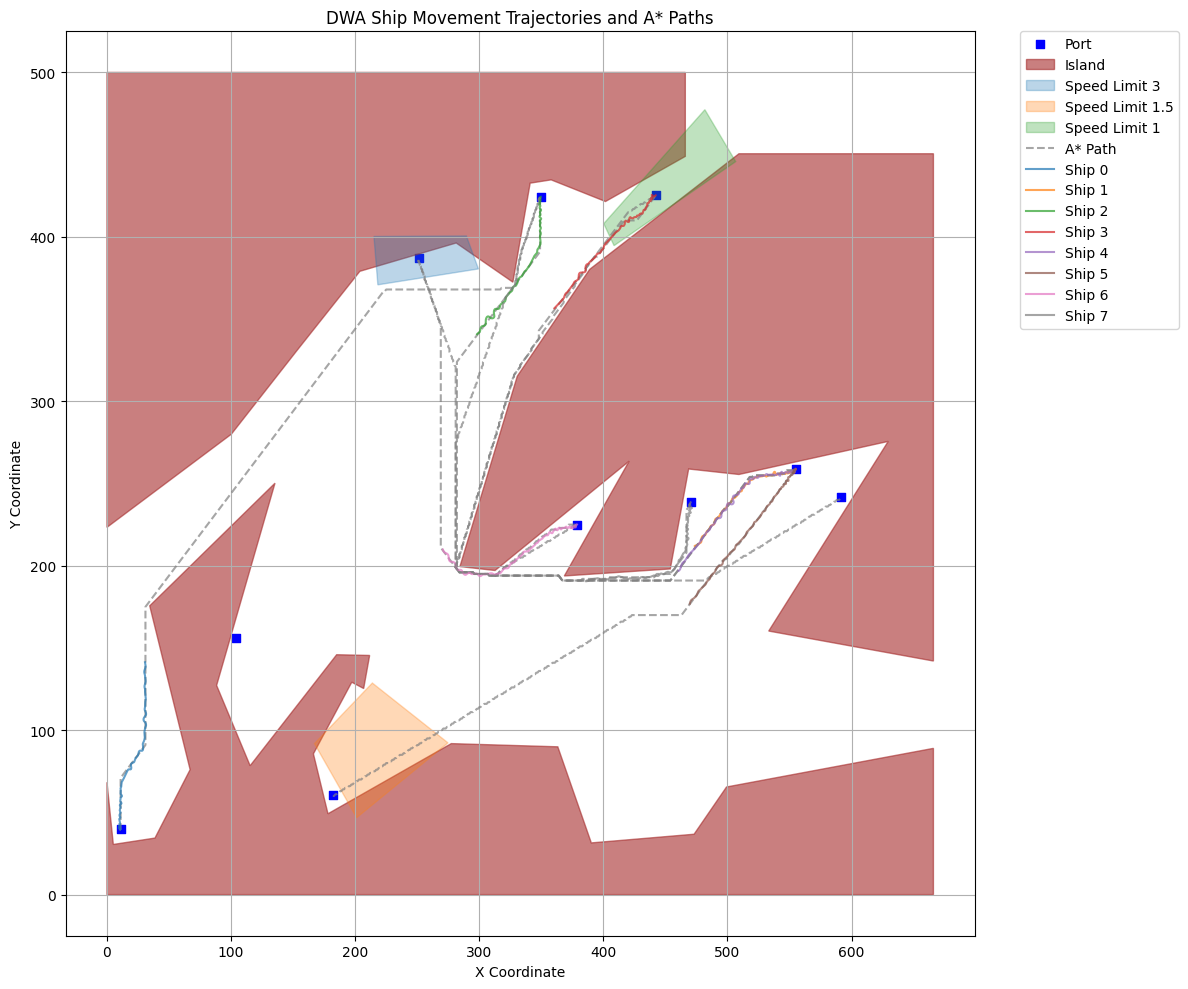

In [50]:
from visualization import plot_simulation

# Run visualization
plot_simulation(df, config)

### Transform Grid to Real-World coordinates

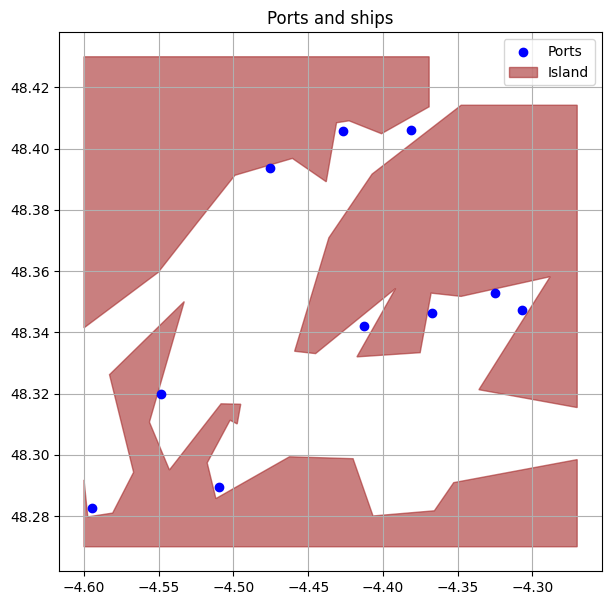

In [52]:
import movingpandas as mpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

start_datetime = datetime.now()
#df = df.drop('AStarPath', axis=1)

def map_to_geocoords(x, y, bounds, width, height):
    lon = bounds["min_lon"] + (x / width) * (bounds["max_lon"] - bounds["min_lon"])
    lat = bounds["min_lat"] + (y / height) * (bounds["max_lat"] - bounds["min_lat"])
    return lon, lat

df[["x", "y"]] = df.apply(
    lambda row: map_to_geocoords(row["x"], row["y"], config["geospatial_bounds"], config["width"], config["height"]),
    axis=1, result_type="expand"
)

time_step_seconds = config["time_step_seconds"]
start_datetime = datetime.now()

df["t"] = df["Step"].apply(lambda step: start_datetime + timedelta(seconds=step * time_step_seconds))

tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=31287)

fig, ax = plt.subplots(figsize=(7,7))

# Transform and plot ports
geo_ports = [map_to_geocoords(x, y, config["geospatial_bounds"], config["width"], config["height"]) for x, y in config["ports"]]
x_coords, y_coords = zip(*geo_ports)
ax.scatter(x_coords, y_coords, color='blue', label='Ports', zorder=5)

# Transform and plot obstacles
for island in config["obstacles"]:
    geo_island = [map_to_geocoords(x, y, config["geospatial_bounds"], config["width"], config["height"]) for x, y in island]
    island_shape = Polygon(geo_island)
    x, y = island_shape.exterior.xy
    ax.fill(x,y, color="brown", alpha=0.6, label="Island" if 'Island' not in plt.gca().get_legend_handles_labels()[1] else "")



ax.grid(True)

# Labels and legend
ax.legend()
ax.set_title("Ports and ships")

plt.show()


In [53]:
import movingpandas as mpd

start_datetime = datetime.now()
df = df.drop('AStarPath', axis=1, errors='ignore'
)
df["t"] = df["Step"].apply(lambda step: start_datetime + timedelta(seconds=step))
tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=31287)

In [54]:
#tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=31287)
tc

TrajectoryCollection with 8 trajectories

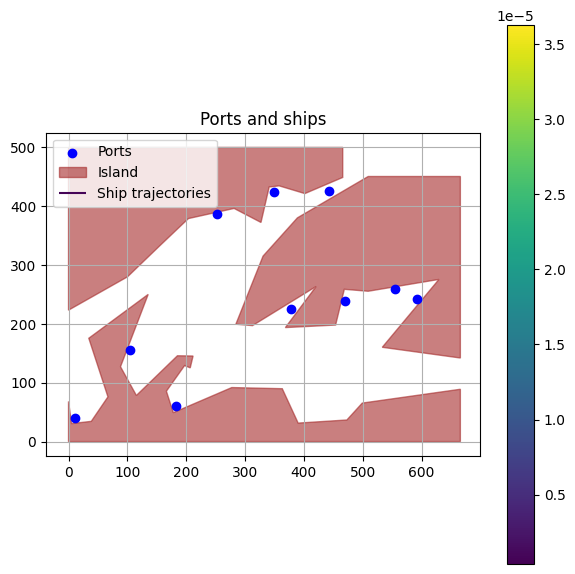

In [55]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

fig, ax = plt.subplots(figsize=(7,7))

x_coords, y_coords = zip(*config["ports"])
ax.scatter(x_coords, y_coords, color='blue', label='Ports', zorder=5)

for island in config["obstacles"]:
    island_shape = Polygon(island)
    x, y = island_shape.exterior.xy
    ax.fill(x, y, color="brown", alpha=0.6, label="Island" if 'Island' not in plt.gca().get_legend_handles_labels()[1] else "")

tc.plot(ax=ax, label='Ship trajectories', column='speed', legend=True)
ax.grid(True)

# Labels and legend
ax.legend()
ax.set_title("Ports and ships")

plt.show()

In [43]:
try:
    tc.trajectories[0].hvplot()
except:
    pass

In [44]:
import os

tc.add_speed(overwrite=True, n_threads=os.cpu_count())
tc.trajectories[0].df#.hvplot(c='speed')

/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Missing optional dependencies. To use the trajectory smoother classes please install Stone Soup (see https://stonesoup.readthedocs.io/en/latest/#installation).
  warnings.warn(e.msg, UserWarning)
/home/romeo/miniconda3/envs/PFE/lib/python3.9/site-packages/movingpandas/__init__.py:41: UserWarning: Miss

,Step,AgentID,geometry,speed
t,,,,
2025-09-04 10:59:49.637812,0,0,POINT (-4.595 48.283),6.946924e-07
2025-09-04 10:59:50.637812,1,0,POINT (-4.595 48.283),6.946924e-07
2025-09-04 10:59:51.637812,2,0,POINT (-4.595 48.283),1.406939e-06
2025-09-04 10:59:52.637812,3,0,POINT (-4.595 48.283),1.370301e-06
2025-09-04 10:59:53.637812,4,0,POINT (-4.595 48.283),1.329399e-06
...,...,...,...,...
2025-09-04 11:59:45.637812,3596,0,POINT (-4.584 48.315),1.839461e-05
2025-09-04 11:59:46.637812,3597,0,POINT (-4.584 48.315),1.864176e-05
2025-09-04 11:59:47.637812,3598,0,POINT (-4.584 48.315),1.892960e-05


In [56]:
sim_result = tc.to_point_gdf()
sim_result['x'] = sim_result.geometry.x
sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'sim_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulation results to {sim_out_file_name}')
sim_result#[sim_result['speed'] > 0.6]

Saved simulation results to sim_20250904_113151.csv


,Step,AgentID,geometry,x,y
t,,,,,
2025-09-04 11:31:43.094895,0,0,POINT (-4.595 48.283),-4.594589,48.282727
2025-09-04 11:31:44.094895,1,0,POINT (-4.595 48.283),-4.594590,48.282727
2025-09-04 11:31:45.094895,2,0,POINT (-4.595 48.283),-4.594591,48.282728
2025-09-04 11:31:46.094895,3,0,POINT (-4.595 48.283),-4.594593,48.282729
2025-09-04 11:31:47.094895,4,0,POINT (-4.595 48.283),-4.594595,48.282730
...,...,...,...,...,...
2025-09-04 12:31:39.094895,3596,7,POINT (-4.409 48.331),-4.408588,48.330988
2025-09-04 12:31:40.094895,3597,7,POINT (-4.409 48.331),-4.408618,48.330989
2025-09-04 12:31:41.094895,3598,7,POINT (-4.409 48.331),-4.408648,48.330990


## Anomaly Simulation

In [11]:
import numpy as np
import pandas as pd
import movingpandas as mpd
from datetime import datetime, timedelta

In [12]:
sim_out_file_name = 'sim_20250902_134304.csv'
PERCENTAGE_OF_ANOMALIES = 0.05

In [13]:
sims = pd.read_csv(sim_out_file_name)
sims

,t,Step,AgentID,geometry,speed,x,y
0,2025-09-02 13:42:17.955294,0,0,POINT (-4.440986813377944 48.37595799683991),0.000006,-4.440987,48.375958
1,2025-09-02 13:42:18.955294,1,0,POINT (-4.440991769509718 48.375954024767985),0.000006,-4.440992,48.375954
2,2025-09-02 13:42:19.955294,2,0,POINT (-4.440997221254668 48.37594965548887),0.000007,-4.440997,48.375950
3,2025-09-02 13:42:20.955294,3,0,POINT (-4.441003168612797 48.375944889002554),0.000008,-4.441003,48.375945
4,2025-09-02 13:42:21.955294,4,0,POINT (-4.441009611584103 48.37593972530905),0.000008,-4.441010,48.375940
...,...,...,...,...,...,...,...
49528,2025-09-02 14:07:13.955294,1496,39,POINT (-4.442361467790267 48.37381152325975),0.000095,-4.442361,48.373812
49529,2025-09-02 14:07:14.955294,1497,39,POINT (-4.442322480817467 48.37389934051111),0.000096,-4.442322,48.373899
49530,2025-09-02 14:07:15.955294,1498,39,POINT (-4.442283248114587 48.373987711263766),0.000097,-4.442283,48.373988
49531,2025-09-02 14:07:16.955294,1499,39,POINT (-4.442243769681629 48.374076635517724),0.000097,-4.442244,48.374077


In [14]:
#sims = sims[sims.AgentID<29].copy()
sims['is_anomaly'] = False
sims['anomaly_type'] = 'n/a'


In [15]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import movingpandas as mpd

# Assure-toi que 't' est bien en datetime
sims = sims.copy()
sims['t'] = pd.to_datetime(sims['t'])

# 1) Créer la colonne geometry à partir de x,y
sims_gdf = gpd.GeoDataFrame(
    sims,
    geometry=gpd.points_from_xy(sims['x'], sims['y']),
    crs=31287   # Maintenant OK, car geometry est définie
)

# 2) Trier par AgentID et temps (bonnes pratiques)
sims_gdf = sims_gdf.sort_values(['AgentID', 't'])

# 3) Créer la TrajectoryCollection (plus besoin de x,y ici)
tc = mpd.TrajectoryCollection(sims_gdf, traj_id_col='AgentID', t='t')


tc

TrajectoryCollection with 33 trajectories

In [16]:
# Remove stopped segments (with speed < 0.0001)
tc = mpd.SpeedSplitter(tc).split(speed=0.0001, duration=timedelta(seconds=5))
tc

TrajectoryCollection with 94 trajectories

### Speed

Change the timestamps to make a subsection of the trajectory faster

In [17]:
unique_ids = sims.AgentID.unique()
unique_ids

array([ 0,  1,  2,  3,  5,  6,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20, 22, 23, 24, 26, 27, 28, 29, 30, 31, 34, 35, 36, 37, 39])

In [18]:
sample_ids_pd = pd.Series(unique_ids).sample(frac=PERCENTAGE_OF_ANOMALIES).tolist()
print("Subset we'll insert anomalies in: ", sample_ids_pd)

Subset we'll insert anomalies in:  [39, 1]


In [19]:
def inject_speed_anomaly(traj, duration_pct=(0.1,0.2), speedup_pct=(1.5,2.5)):
    df = traj.df.copy()
    df.reset_index(inplace=True)
    df["t_diff"] = df['t'].diff()
    # Choose within middle range
    total_steps = len(df)
    anomaly_start_idx = np.random.randint(0.1 * total_steps, 0.8 * total_steps)  
    duration_pct = duration_pct[0] + (np.random.random() * (duration_pct[1]-duration_pct[0]))
    anomaly_duration = int(duration_pct * total_steps)  
    # Insert new values
    speedup_pct = speedup_pct[0] + (np.random.random() * (speedup_pct[1]-speedup_pct[0]))
    new_vals = df.iloc[anomaly_start_idx : anomaly_start_idx + anomaly_duration].t_diff / speedup_pct
    df.loc[anomaly_start_idx : anomaly_start_idx + anomaly_duration -1, "t_diff"] = new_vals
    # Flag anomalies
    df.loc[anomaly_start_idx : anomaly_start_idx + anomaly_duration -1, "is_anomaly"] = True
    df.loc[anomaly_start_idx : anomaly_start_idx + anomaly_duration -1, "anomaly_type"] = 'speed'

    # Correct the timestamp update logic
    df["t"] = df["t"].iloc[0] + df["t_diff"].fillna(pd.Timedelta(seconds=0)).cumsum()
    return mpd.Trajectory(df,t='t',traj_id=traj.id)

<Axes: >

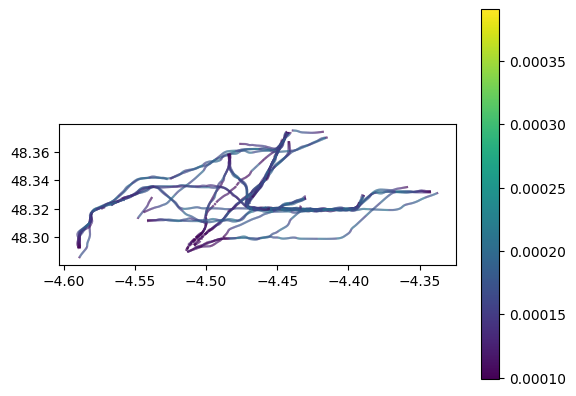

In [20]:
for i, traj in enumerate(tc.trajectories):
    if i in sample_ids_pd: 
        traj = inject_speed_anomaly(traj)
        tc.trajectories[i] = traj
    
tc.add_speed(overwrite=True)
tc.plot(column='speed', legend=True)

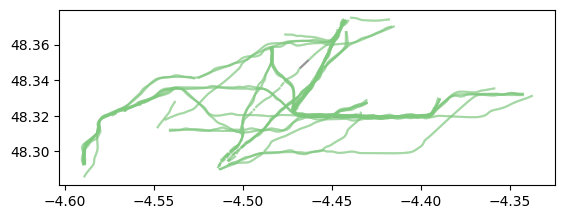

In [21]:
ax = tc.plot(column='is_anomaly', cmap='Accent')

In [22]:
try:
    tc.trajectories[0].hvplot(c='speed')
except:
    pass

In [23]:
sim_result = tc.to_point_gdf()
sim_result['x'] = sim_result.geometry.x
sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'anomalies_speed_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulated speed anomalies to {sim_out_file_name}')

Saved simulated speed anomalies to anomalies_speed_20250903_152634.csv


### Location

#### Generate trajectories that pass through obstacles

Note that is not guaranteed that each resulting trajectory will pass through an obtacle! Ships simply ignore the obstacles.

In [24]:
import logging
from datetime import datetime, timedelta
import json

from model import ShipModel
from agents.ship import Ship

logging.basicConfig(
    filename="notebook_logs.log",
    filemode="w",  # Overwrites on each run; use "a" to append
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

config_file="config/config.json"
with open(config_file) as f:
    config = json.load(f)

steps = config["simulation_steps"]
    
model = ShipModel(
        width=config["width"],
        height=config["height"],
        num_ships=int(config["num_ships"]*2*PERCENTAGE_OF_ANOMALIES), # doubling the number, assuming that 50% will violate obstacles
        max_speed_range=config["max_speed_range"],
        ports=config["ports"],
        speed_limit_zones=config.get("speed_limit_zones", []),
        obstacles=[config["obstacles"][0]], # Here we only select the first obstacle that describes the main land mass
        dwa_config=config["dwa_config"],
        resolution=config["resolution"],
        obstacle_threshold=config["obstacle_threshold"],
        lookahead=config["lookahead"],
        speed_variation=config.get("speed_variation", 0.1),           # 
        directional_variation=config.get("directional_variation", 5)  #
    )

In [25]:
print(f"{datetime.now()} Starting ...")
for t in range(steps):
    stride = 50
    if t%stride == 0:
        print(f"Steps {t} - {t+stride-1}...")
    model.step()
print(f"{datetime.now()} Finished.")

2025-09-03 15:26:36.359219 Starting ...
Steps 0 - 49...
Steps 50 - 99...
Steps 100 - 149...
Steps 150 - 199...
Steps 200 - 249...
Steps 250 - 299...
Steps 300 - 349...
Steps 350 - 399...
Steps 400 - 449...
Steps 450 - 499...
Steps 500 - 549...
Steps 550 - 599...
Steps 600 - 649...
Steps 650 - 699...
Steps 700 - 749...
Steps 750 - 799...
Steps 800 - 849...
Steps 850 - 899...
Steps 900 - 949...
Steps 950 - 999...
Steps 1000 - 1049...
Steps 1050 - 1099...
Steps 1100 - 1149...
Steps 1150 - 1199...
Steps 1200 - 1249...
Steps 1250 - 1299...
Steps 1300 - 1349...
Steps 1350 - 1399...
Steps 1400 - 1449...
Steps 1450 - 1499...
2025-09-03 15:28:50.866962 Finished.


In [26]:
agent_df = model.datacollector.get_agent_vars_dataframe().dropna()
df = agent_df.reset_index()
df

,Step,AgentID,x,y,AStarPath
0,0,0,250.195753,90.029012,"[(250.0, 90.0), (249.0, 90.0), (248.0, 90.0), ..."
1,0,1,7.214540,15.908203,"[(7.0, 15.0), (8.0, 15.0), (9.0, 15.0), (10.0,..."
2,0,2,166.253584,154.756305,"[(166.0, 154.0), (167.0, 153.0), (168.0, 153.0..."
3,0,3,68.573166,62.428321,"[(68.0, 62.0), (69.0, 63.0), (70.0, 64.0), (71..."
4,1,1,7.214840,15.907202,"[(7.0, 15.0), (8.0, 15.0), (9.0, 15.0), (10.0,..."
...,...,...,...,...,...
5999,1499,1,29.259401,24.550081,"[(7.0, 15.0), (8.0, 15.0), (9.0, 15.0), (10.0,..."
6000,1500,0,224.753045,90.250173,"[(250.0, 90.0), (249.0, 90.0), (248.0, 90.0), ..."
6001,1500,1,29.292227,24.552709,"[(7.0, 15.0), (8.0, 15.0), (9.0, 15.0), (10.0,..."
6002,1500,3,83.252977,74.839623,"[(68.0, 62.0), (69.0, 63.0), (70.0, 64.0), (71..."


Saved simulation plot to simulation_plot.png


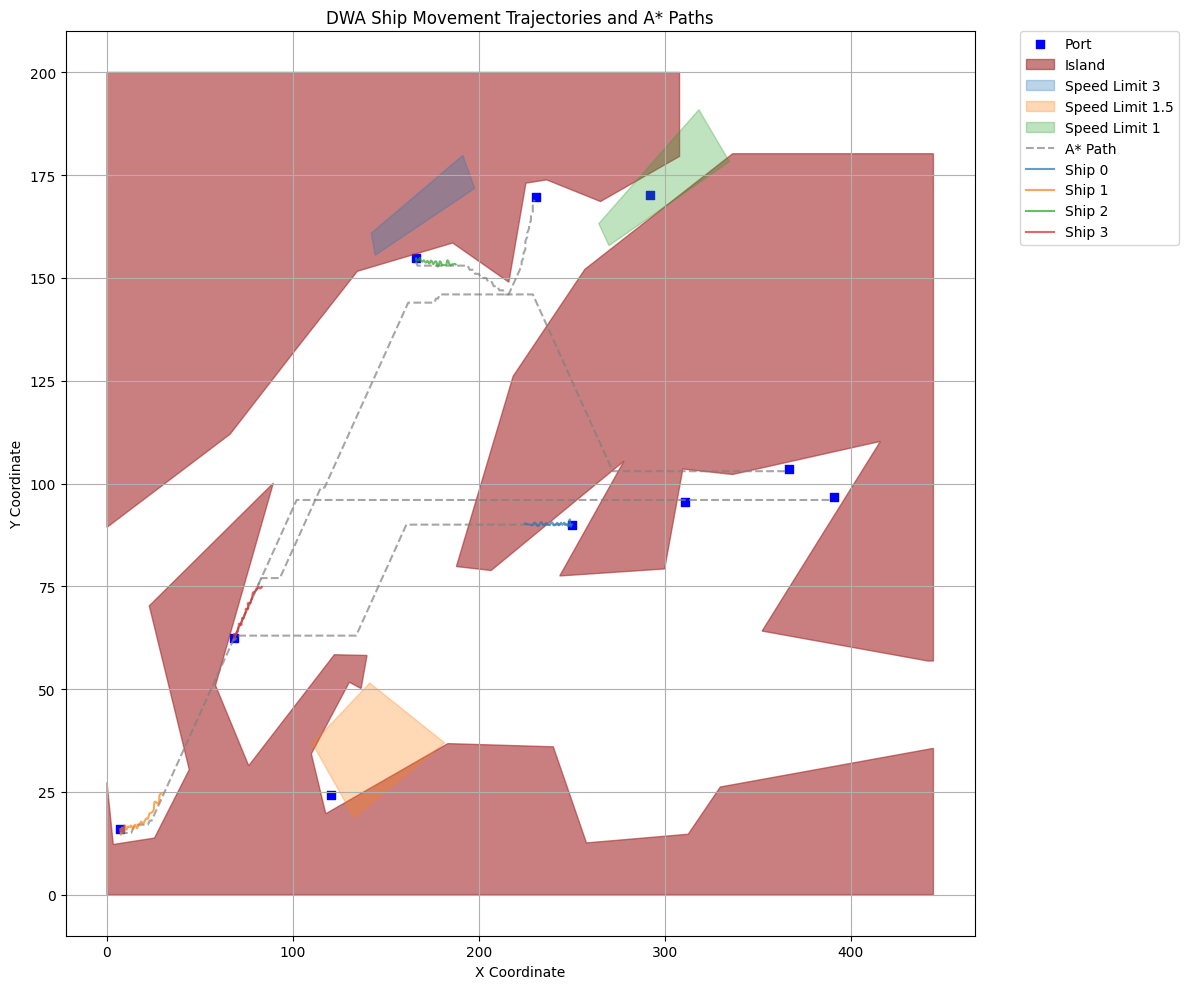

In [27]:
from visualization import plot_simulation
plot_simulation(df, config)

In [28]:
import movingpandas as mpd

start_datetime = datetime.now()
df = df.drop('AStarPath', axis=1)
df["t"] = df["Step"].apply(lambda step: start_datetime + timedelta(seconds=step))
tc = mpd.TrajectoryCollection(df, traj_id_col='AgentID', t='t', x='x', y='y', crs=31287)

In [29]:
tc.add_speed(overwrite=True)
tc.trajectories[0].df

,Step,AgentID,geometry,speed
t,,,,
2025-09-03 15:28:51.726487,0,0,POINT (250.196 90.029),0.000053
2025-09-03 15:28:52.726487,1,0,POINT (250.196 90.029),0.000053
2025-09-03 15:28:53.726487,2,0,POINT (250.196 90.029),0.000019
2025-09-03 15:28:54.726487,3,0,POINT (250.196 90.029),0.000174
2025-09-03 15:28:55.726487,4,0,POINT (250.195 90.029),0.000441
...,...,...,...,...
2025-09-03 15:53:47.726487,1496,0,POINT (224.862 90.242),0.027426
2025-09-03 15:53:48.726487,1497,0,POINT (224.835 90.244),0.027438
2025-09-03 15:53:49.726487,1498,0,POINT (224.808 90.246),0.027390


In [30]:
sim_result = tc.to_point_gdf()
sim_result['x'] = sim_result.geometry.x
sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'sim_no-obstacles_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulation results to {sim_out_file_name}')

Saved simulation results to sim_no-obstacles_20250903_152852.csv


#### Flag anomalies

In [31]:
sims = pd.read_csv(sim_out_file_name)
sims

,t,Step,AgentID,geometry,speed,x,y
0,2025-09-03 15:28:51.726487,0,0,POINT (250.19575278361827 90.02901168407732),0.000053,250.195753,90.029012
1,2025-09-03 15:28:52.726487,1,0,POINT (250.19570032621394 90.02901835550212),0.000053,250.195700,90.029018
2,2025-09-03 15:28:53.726487,2,0,POINT (250.19568685525905 90.02903178770696),0.000019,250.195687,90.029032
3,2025-09-03 15:28:54.726487,3,0,POINT (250.19551421365617 90.02901417405376),0.000174,250.195514,90.029014
4,2025-09-03 15:28:55.726487,4,0,POINT (250.1950751196926 90.02897714160851),0.000441,250.195075,90.028977
...,...,...,...,...,...,...,...
5999,2025-09-03 15:53:47.726487,1496,3,POINT (83.16744842425427 74.81152745297065),0.022326,83.167448,74.811527
6000,2025-09-03 15:53:48.726487,1497,3,POINT (83.18873350856046 74.81851141021478),0.022402,83.188734,74.818511
6001,2025-09-03 15:53:49.726487,1498,3,POINT (83.21008663888655 74.82552880225428),0.022477,83.210087,74.825529
6002,2025-09-03 15:53:50.726487,1499,3,POINT (83.23155541476473 74.8325835617288),0.022598,83.231555,74.832584


In [32]:
#sims = sims[sims.AgentID<22].copy()
sims['is_anomaly'] = False
sims['anomaly_type'] = 'n/a'
sims["geometry"] = [Point(xy) for xy in zip(sims["x"], sims["y"])]

tc = mpd.TrajectoryCollection(sims, t='t', traj_id_col='AgentID', x='x', y='y', crs=4326)
tc

TrajectoryCollection with 4 trajectories

<Axes: >

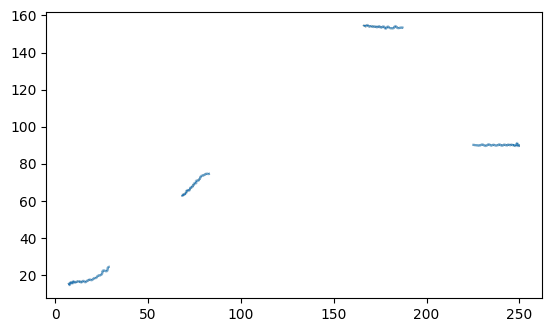

In [33]:
tc.plot(aspect="equal")

In [34]:
from shapely.geometry import Polygon
from geopandas import GeoSeries

def inject_location_anomaly(traj, polygon):
    df = traj.df.copy()
    intersecting = df.intersects(polygon)
    df.loc[intersecting, 'is_anomaly'] = True
    df.loc[intersecting, 'anomaly_type'] = 'location'
    return mpd.Trajectory(df,t='t',traj_id=traj.id)

In [35]:

obstacles=config["obstacles"]
polygons=[]

for obstacle in obstacles:
    polygon = Polygon(obstacle)
    polygons.append(polygon)
    for i, traj in enumerate(tc.trajectories):
        traj = inject_location_anomaly(traj, polygon)
        tc.trajectories[i] = traj
    

<Axes: >

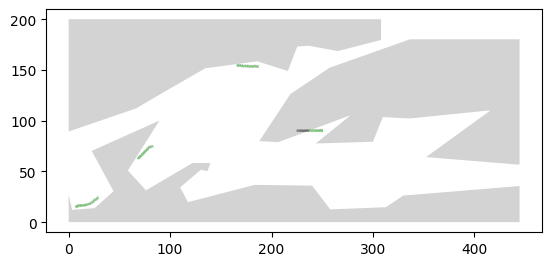

In [36]:
ax = tc.plot(column='is_anomaly', cmap='Accent', aspect="equal")
GeoSeries(polygons).plot(ax=ax, color="lightgray")

In [37]:
sim_result = tc.to_point_gdf()
sim_result['x'] = sim_result.geometry.x
sim_result['y'] = sim_result.geometry.y
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
sim_out_file_name = f'anomalies_loc_{timestamp}.csv'
sim_result.to_csv(sim_out_file_name)
print(f'Saved simulated location anomalies to {sim_out_file_name}')

Saved simulated location anomalies to anomalies_loc_20250903_152853.csv


### Direction

TODO

## Merge files

In [38]:
df1 = pd.read_csv("anomalies_speed_20250902_134524.csv")
df2 = pd.read_csv("anomalies_loc_20250902_140555.csv")
out = pd.concat([df1,df2])[['t','AgentID','speed','is_anomaly','anomaly_type','x','y']]
out.to_csv("synthetic_vessel_tracks_with_anomalies_20250903.csv", index=False)

In [39]:
tmp = pd.read_csv("synthetic_vessel_tracks_with_anomalies_20250517.csv")
tmp

,t,AgentID,speed,is_anomaly,anomaly_type,x,y
0,2025-09-02 13:44:55.955294000,0_0,0.000101,False,NaN,-4.446596,48.369605
1,2025-09-02 13:44:56.955294000,0_0,0.000101,False,NaN,-4.446619,48.369507
2,2025-09-02 13:45:04.955294000,0_1,0.000101,False,NaN,-4.446722,48.368729
3,2025-09-02 13:45:05.955294000,0_1,0.000101,False,NaN,-4.446731,48.368629
4,2025-09-02 13:45:06.955294000,0_1,0.000100,False,NaN,-4.446740,48.368529
...,...,...,...,...,...,...,...
32115,2025-09-02 14:13:53.984431,3,0.010000,False,NaN,292.198364,170.134868
32116,2025-09-02 14:13:54.984431,3,0.010000,False,NaN,292.206968,170.129773
32117,2025-09-02 14:13:55.984431,3,0.010000,False,NaN,292.215294,170.124234
32118,2025-09-02 14:13:56.984431,3,0.010000,False,NaN,292.223319,170.118267


In [40]:
tmp[tmp.anomaly_type=="location"]

,t,AgentID,speed,is_anomaly,anomaly_type,x,y
26223,2025-09-02 13:50:44.984431,0,0.116000,True,location,252.788293,96.126994
26224,2025-09-02 13:50:45.984431,0,0.117000,True,location,252.807874,96.242344
26225,2025-09-02 13:50:46.984431,0,0.118000,True,location,252.827622,96.358680
26226,2025-09-02 13:50:47.984431,0,0.119000,True,location,252.847537,96.476001
26227,2025-09-02 13:50:48.984431,0,0.120000,True,location,252.867620,96.594309
...,...,...,...,...,...,...,...
31125,2025-09-02 13:57:23.984431,3,0.223745,True,location,289.302415,162.737273
31126,2025-09-02 13:57:24.984431,3,0.224745,True,location,289.390714,162.943945
31127,2025-09-02 13:57:25.984431,3,0.225745,True,location,289.479406,163.151537
31128,2025-09-02 13:57:26.984431,3,0.226745,True,location,289.568491,163.360048


In [41]:
tmp[tmp.anomaly_type=="location"].AgentID.unique()

array(['0', '1', '2', '3'], dtype=object)